# WESAD Dataset Visualization and Analysis

이 노트북은 WESAD (Wearable Stress and Affect Detection) 데이터셋을 시각화하고 분석합니다.

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 스타일 설정
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 8)

## 1. 데이터셋 설정

In [6]:
# 경로 설정
DATASET_PATH = '../../Dataset/WESAD'
TARGET_USERS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

# 레이블 정의
LABEL_NAMES = {
    0: 'Not defined',
    1: 'Baseline',
    2: 'Stress', 
    3: 'Amusement',
    4: 'Meditation',
    5: 'Unused',
    6: 'Unused',
    7: 'Unused'
}

# 분석 대상 레이블
TARGET_LABELS = [1, 2, 3]  # Baseline, Stress, Amusement

# 다운샘플링 레이트
DOWNSAMPLE_RATE = 4  # Hz

print(f"데이터셋 경로: {DATASET_PATH}")
print(f"분석 대상 피험자 수: {len(TARGET_USERS)}")
print(f"분석 대상 상태: {[LABEL_NAMES[i] for i in TARGET_LABELS]}")

데이터셋 경로: ../../Dataset/WESAD
분석 대상 피험자 수: 15
분석 대상 상태: ['Baseline', 'Stress', 'Amusement']


## 2. 데이터 로드 함수

In [7]:
def load_subject_data(subject_id):
    """특정 피험자의 데이터를 로드하고 전처리합니다."""
    subject_path = os.path.join(DATASET_PATH, subject_id, f'{subject_id}.pkl')
    
    if not os.path.exists(subject_path):
        print(f"파일을 찾을 수 없습니다: {subject_path}")
        return None
    
    with open(subject_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    
    # 손목 웨어러블 데이터 추출
    wrist_data = data['signal']['wrist']
    
    # 센서 데이터
    acc = wrist_data['ACC']      # Accelerometer (32Hz, 3축)
    bvp = wrist_data['BVP']      # Blood Volume Pulse (64Hz)
    eda = wrist_data['EDA']      # Electrodermal Activity (4Hz)
    temp = wrist_data['TEMP']    # Skin Temperature (4Hz)
    labels = data['label']        # Labels (700Hz)
    
    # 다운샘플링
    acc_down = acc[::32 // DOWNSAMPLE_RATE]
    bvp_down = bvp[::64 // DOWNSAMPLE_RATE]
    eda_down = eda[::4 // DOWNSAMPLE_RATE]
    temp_down = temp[::4 // DOWNSAMPLE_RATE]
    labels_down = labels[::700 // DOWNSAMPLE_RATE]
    
    # 길이 맞추기
    min_len = min(len(acc_down), len(bvp_down), len(eda_down), len(temp_down), len(labels_down))
    
    return {
        'subject_id': subject_id,
        'acc': acc_down[:min_len],
        'bvp': bvp_down[:min_len],
        'eda': eda_down[:min_len],
        'temp': temp_down[:min_len],
        'labels': labels_down[:min_len].astype(int),
        'sampling_rate': DOWNSAMPLE_RATE,
        'length': min_len
    }

print("데이터 로드 함수 정의 완료")

데이터 로드 함수 정의 완료


## 3. 샘플 데이터 로드 및 탐색

In [8]:
# S2 피험자 데이터 로드
sample_subject = 'S2'
data = load_subject_data(sample_subject)

if data is not None:
    print(f"\n=== {sample_subject} 피험자 데이터 정보 ===")
    print(f"샘플링 레이트: {data['sampling_rate']} Hz")
    print(f"총 샘플 수: {data['length']:,}")
    print(f"총 시간: {data['length'] / data['sampling_rate'] / 60:.2f} 분")
    print(f"\nACC shape: {data['acc'].shape}")
    print(f"BVP shape: {data['bvp'].shape}")
    print(f"EDA shape: {data['eda'].shape}")
    print(f"TEMP shape: {data['temp'].shape}")
    print(f"Labels shape: {data['labels'].shape}")
    
    # 레이블 분포
    print(f"\n=== 레이블 분포 ===")
    unique_labels, counts = np.unique(data['labels'], return_counts=True)
    for label, count in zip(unique_labels, counts):
        percentage = (count / len(data['labels'])) * 100
        duration_min = count / data['sampling_rate'] / 60
        label_name = LABEL_NAMES.get(label, 'Unknown')
        print(f"{label_name} (label {label}): {count:,} samples ({percentage:.1f}%, {duration_min:.2f}분)")


=== S2 피험자 데이터 정보 ===
샘플링 레이트: 4 Hz
총 샘플 수: 24,316
총 시간: 101.32 분

ACC shape: (24316, 3)
BVP shape: (24316, 1)
EDA shape: (24316, 1)
TEMP shape: (24316, 1)
Labels shape: (24316,)

=== 레이블 분포 ===
Not defined (label 0): 12,244 samples (50.4%, 51.02분)
Baseline (label 1): 4,576 samples (18.8%, 19.07분)
Stress (label 2): 2,460 samples (10.1%, 10.25분)
Amusement (label 3): 1,448 samples (6.0%, 6.03분)
Meditation (label 4): 3,072 samples (12.6%, 12.80분)
Unused (label 6): 260 samples (1.1%, 1.08분)
Unused (label 7): 256 samples (1.1%, 1.07분)


## 4. 전체 시계열 데이터 시각화

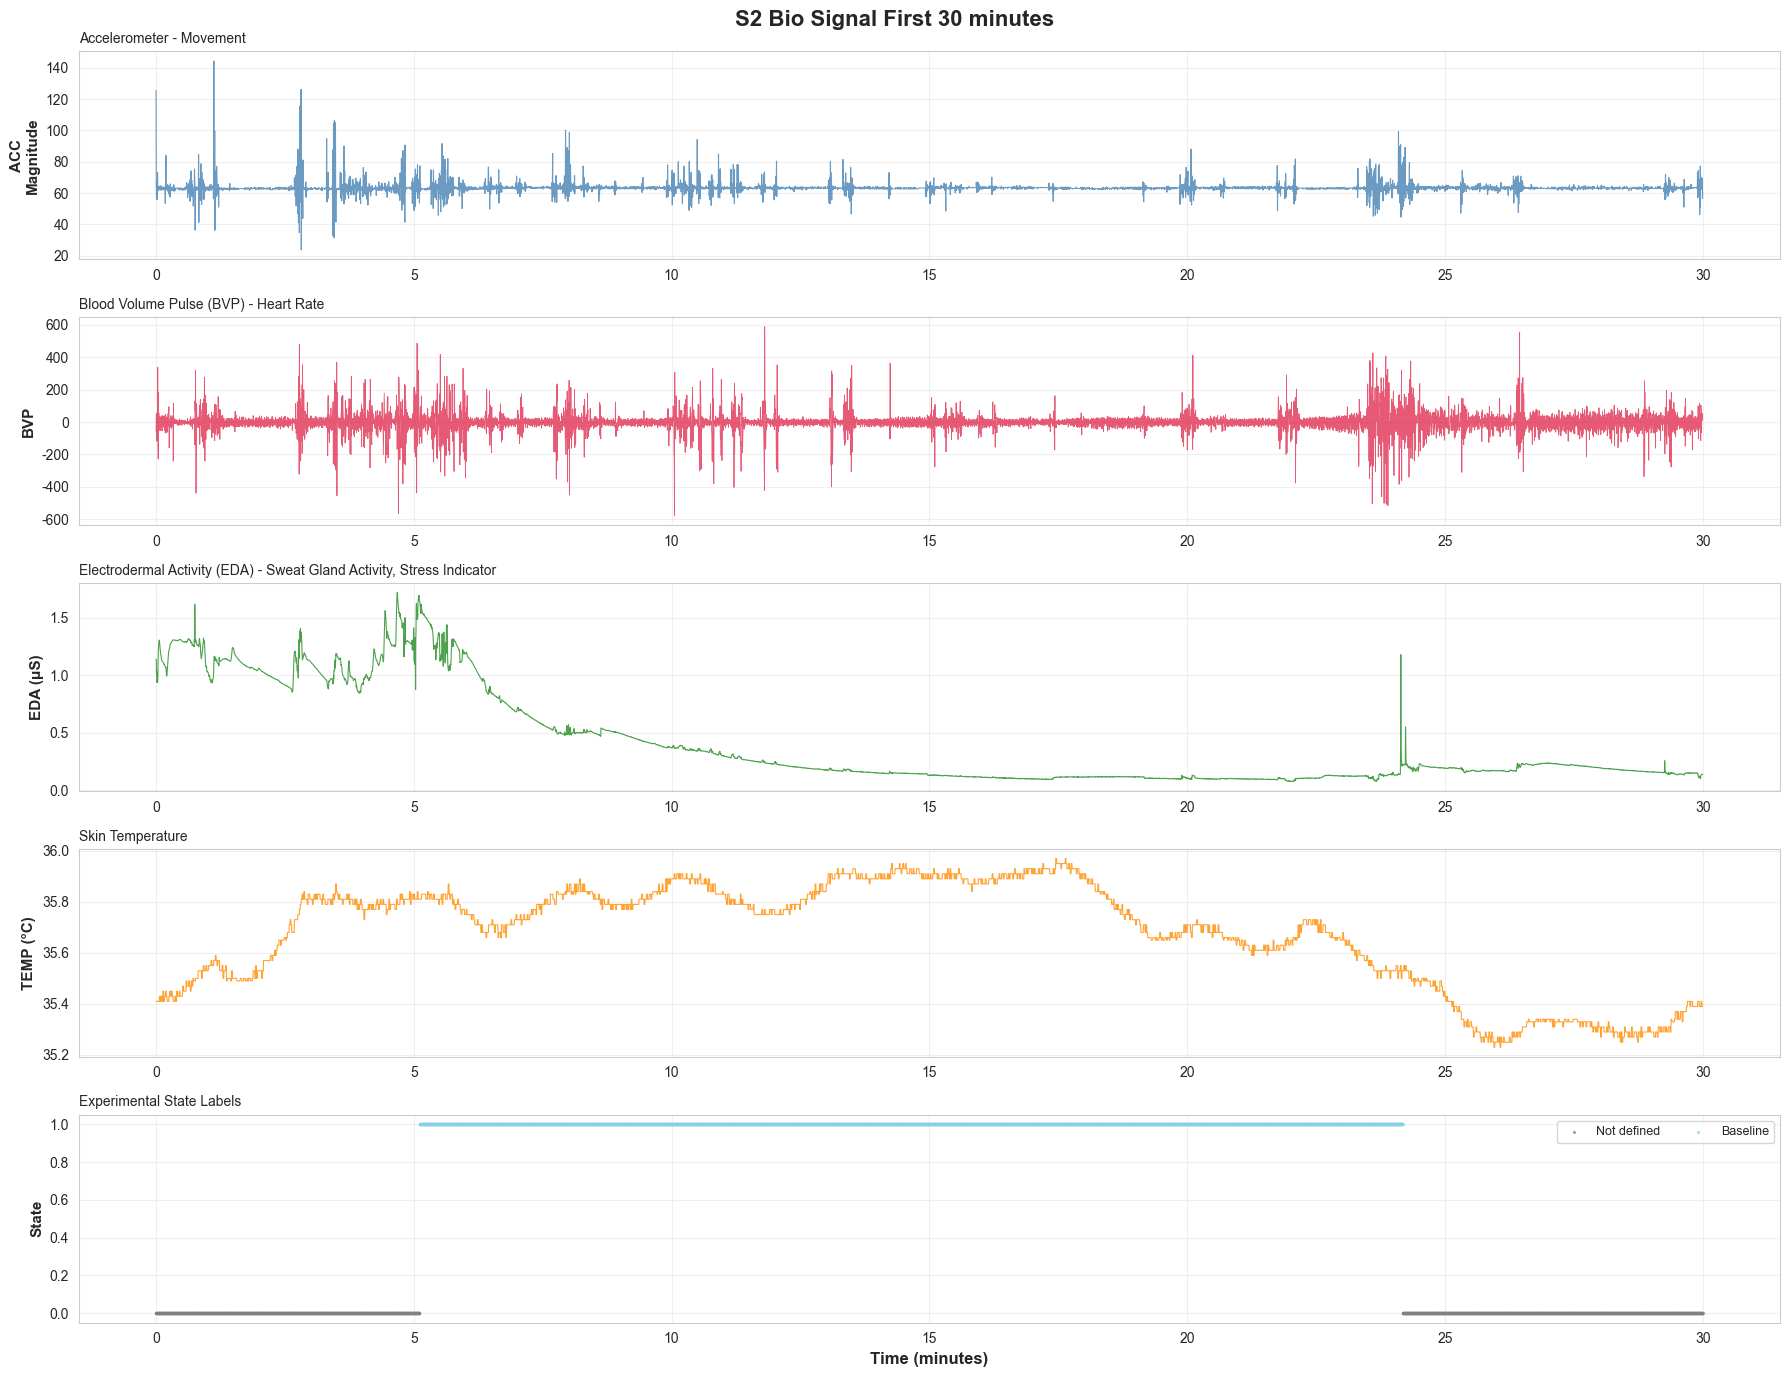

In [10]:
if data is not None:
    # 전체 데이터의 일부만 표시 (처음 30분)
    plot_duration_min = 30
    plot_samples = int(plot_duration_min * 60 * data['sampling_rate'])
    plot_samples = min(plot_samples, data['length'])
    
    time_axis = np.arange(plot_samples) / data['sampling_rate'] / 60  # 분 단위
    
    fig, axes = plt.subplots(5, 1, figsize=(18, 14))
    fig.suptitle(f'{sample_subject} Bio Signal First {plot_duration_min} minutes', fontsize=16, fontweight='bold')
    
    # 1. ACC Magnitude
    acc_mag = np.sqrt(np.sum(data['acc'][:plot_samples]**2, axis=1))
    axes[0].plot(time_axis, acc_mag, linewidth=0.8, color='steelblue', alpha=0.8)
    axes[0].set_ylabel('ACC\nMagnitude', fontsize=11, fontweight='bold')
    axes[0].set_title('Accelerometer - Movement', fontsize=10, loc='left')
    axes[0].grid(True, alpha=0.3)
    
    # 2. BVP
    axes[1].plot(time_axis, data['bvp'][:plot_samples, 0], linewidth=0.6, color='crimson', alpha=0.7)
    axes[1].set_ylabel('BVP', fontsize=11, fontweight='bold')
    axes[1].set_title('Blood Volume Pulse (BVP) - Heart Rate', fontsize=10, loc='left')
    axes[1].grid(True, alpha=0.3)
    
    # 3. EDA
    axes[2].plot(time_axis, data['eda'][:plot_samples, 0], linewidth=0.8, color='forestgreen', alpha=0.8)
    axes[2].set_ylabel('EDA (μS)', fontsize=11, fontweight='bold')
    axes[2].set_title('Electrodermal Activity (EDA) - Sweat Gland Activity, Stress Indicator', fontsize=10, loc='left')
    axes[2].grid(True, alpha=0.3)
    
    # 4. TEMP
    axes[3].plot(time_axis, data['temp'][:plot_samples, 0], linewidth=0.8, color='darkorange', alpha=0.8)
    axes[3].set_ylabel('TEMP (°C)', fontsize=11, fontweight='bold')
    axes[3].set_title('Skin Temperature', fontsize=10, loc='left')
    axes[3].grid(True, alpha=0.3)
    
    # 5. Labels (상태)
    colors = {0: 'gray', 1: 'skyblue', 2: 'salmon', 3: 'lightgreen', 4: 'plum'}
    for label_val in np.unique(data['labels'][:plot_samples]):
        mask = data['labels'][:plot_samples] == label_val
        axes[4].scatter(time_axis[mask], [label_val]*mask.sum(), 
                       s=2, alpha=0.6, c=colors.get(label_val, 'gray'), 
                       label=LABEL_NAMES.get(label_val, f'Label {label_val}'))
    
    axes[4].set_ylabel('State', fontsize=11, fontweight='bold')
    axes[4].set_xlabel('Time (minutes)', fontsize=12, fontweight='bold')
    axes[4].set_title('Experimental State Labels', fontsize=10, loc='left')
    axes[4].legend(loc='upper right', ncol=5, fontsize=9)
    axes[4].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 5. 각 상태별 센서 데이터 통계 분석

In [11]:
if data is not None:
    stats_list = []
    
    for label_val in TARGET_LABELS:
        mask = data['labels'] == label_val
        
        if mask.sum() == 0:
            continue
        
        # ACC magnitude
        acc_mag = np.sqrt(np.sum(data['acc'][mask]**2, axis=1))
        
        stats = {
            '상태': LABEL_NAMES[label_val],
            '샘플 수': mask.sum(),
            '시간(분)': mask.sum() / data['sampling_rate'] / 60,
            'BVP 평균': data['bvp'][mask].mean(),
            'BVP 표준편차': data['bvp'][mask].std(),
            'EDA 평균': data['eda'][mask].mean(),
            'EDA 표준편차': data['eda'][mask].std(),
            '온도 평균': data['temp'][mask].mean(),
            '온도 표준편차': data['temp'][mask].std(),
            'ACC 크기 평균': acc_mag.mean(),
            'ACC 크기 표준편차': acc_mag.std()
        }
        stats_list.append(stats)
    
    df_stats = pd.DataFrame(stats_list)
    print(f"\n=== {sample_subject} 피험자의 상태별 센서 데이터 통계 ===\n")
    print(df_stats.to_string(index=False))


=== S2 피험자의 상태별 센서 데이터 통계 ===

       상태  샘플 수     시간(분)    BVP 평균  BVP 표준편차   EDA 평균  EDA 표준편차     온도 평균  온도 표준편차  ACC 크기 평균  ACC 크기 표준편차
 Baseline  4576 19.066667 -0.358011 64.911004 0.297881  0.309248 35.786198 0.108444  63.403876     3.016676
   Stress  2460 10.250000 -0.635020 76.083655 0.870277  0.204461 33.442098 0.462643  63.010803     2.688511
Amusement  1448  6.033333 -0.199344 48.090798 0.206203  0.038276 34.190884 0.120213  63.258529     1.618727


## 6. Baseline 대비 변화율 분석

In [12]:
if data is not None and len(df_stats) > 0:
    print("\n=== Baseline 대비 상대적 변화 ===\n")
    
    baseline_row = df_stats[df_stats['상태'] == 'Baseline']
    if len(baseline_row) > 0:
        baseline_bvp = baseline_row['BVP 평균'].values[0]
        baseline_eda = baseline_row['EDA 평균'].values[0]
        baseline_temp = baseline_row['온도 평균'].values[0]
        baseline_acc = baseline_row['ACC 크기 평균'].values[0]
        
        for _, row in df_stats.iterrows():
            state = row['상태']
            print(f"\n[{state}]")
            
            if state != 'Baseline':
                bvp_change = ((row['BVP 평균'] - baseline_bvp) / abs(baseline_bvp)) * 100
                eda_change = ((row['EDA 평균'] - baseline_eda) / baseline_eda) * 100
                temp_change = ((row['온도 평균'] - baseline_temp) / baseline_temp) * 100
                acc_change = ((row['ACC 크기 평균'] - baseline_acc) / baseline_acc) * 100
                
                print(f"  BVP: {row['BVP 평균']:.4f} (Baseline 대비 {bvp_change:+.2f}%)")
                print(f"  EDA: {row['EDA 평균']:.4f} (Baseline 대비 {eda_change:+.2f}%)")
                print(f"  온도: {row['온도 평균']:.4f} (Baseline 대비 {temp_change:+.2f}%)")
                print(f"  ACC: {row['ACC 크기 평균']:.4f} (Baseline 대비 {acc_change:+.2f}%)")
            else:
                print(f"  BVP: {row['BVP 평균']:.4f} (기준)")
                print(f"  EDA: {row['EDA 평균']:.4f} (기준)")
                print(f"  온도: {row['온도 평균']:.4f} (기준)")
                print(f"  ACC: {row['ACC 크기 평균']:.4f} (기준)")


=== Baseline 대비 상대적 변화 ===


[Baseline]
  BVP: -0.3580 (기준)
  EDA: 0.2979 (기준)
  온도: 35.7862 (기준)
  ACC: 63.4039 (기준)

[Stress]
  BVP: -0.6350 (Baseline 대비 -77.37%)
  EDA: 0.8703 (Baseline 대비 +192.16%)
  온도: 33.4421 (Baseline 대비 -6.55%)
  ACC: 63.0108 (Baseline 대비 -0.62%)

[Amusement]
  BVP: -0.1993 (Baseline 대비 +44.32%)
  EDA: 0.2062 (Baseline 대비 -30.78%)
  온도: 34.1909 (Baseline 대비 -4.46%)
  ACC: 63.2585 (Baseline 대비 -0.23%)


## 7. 상태별 센서 데이터 분포 비교

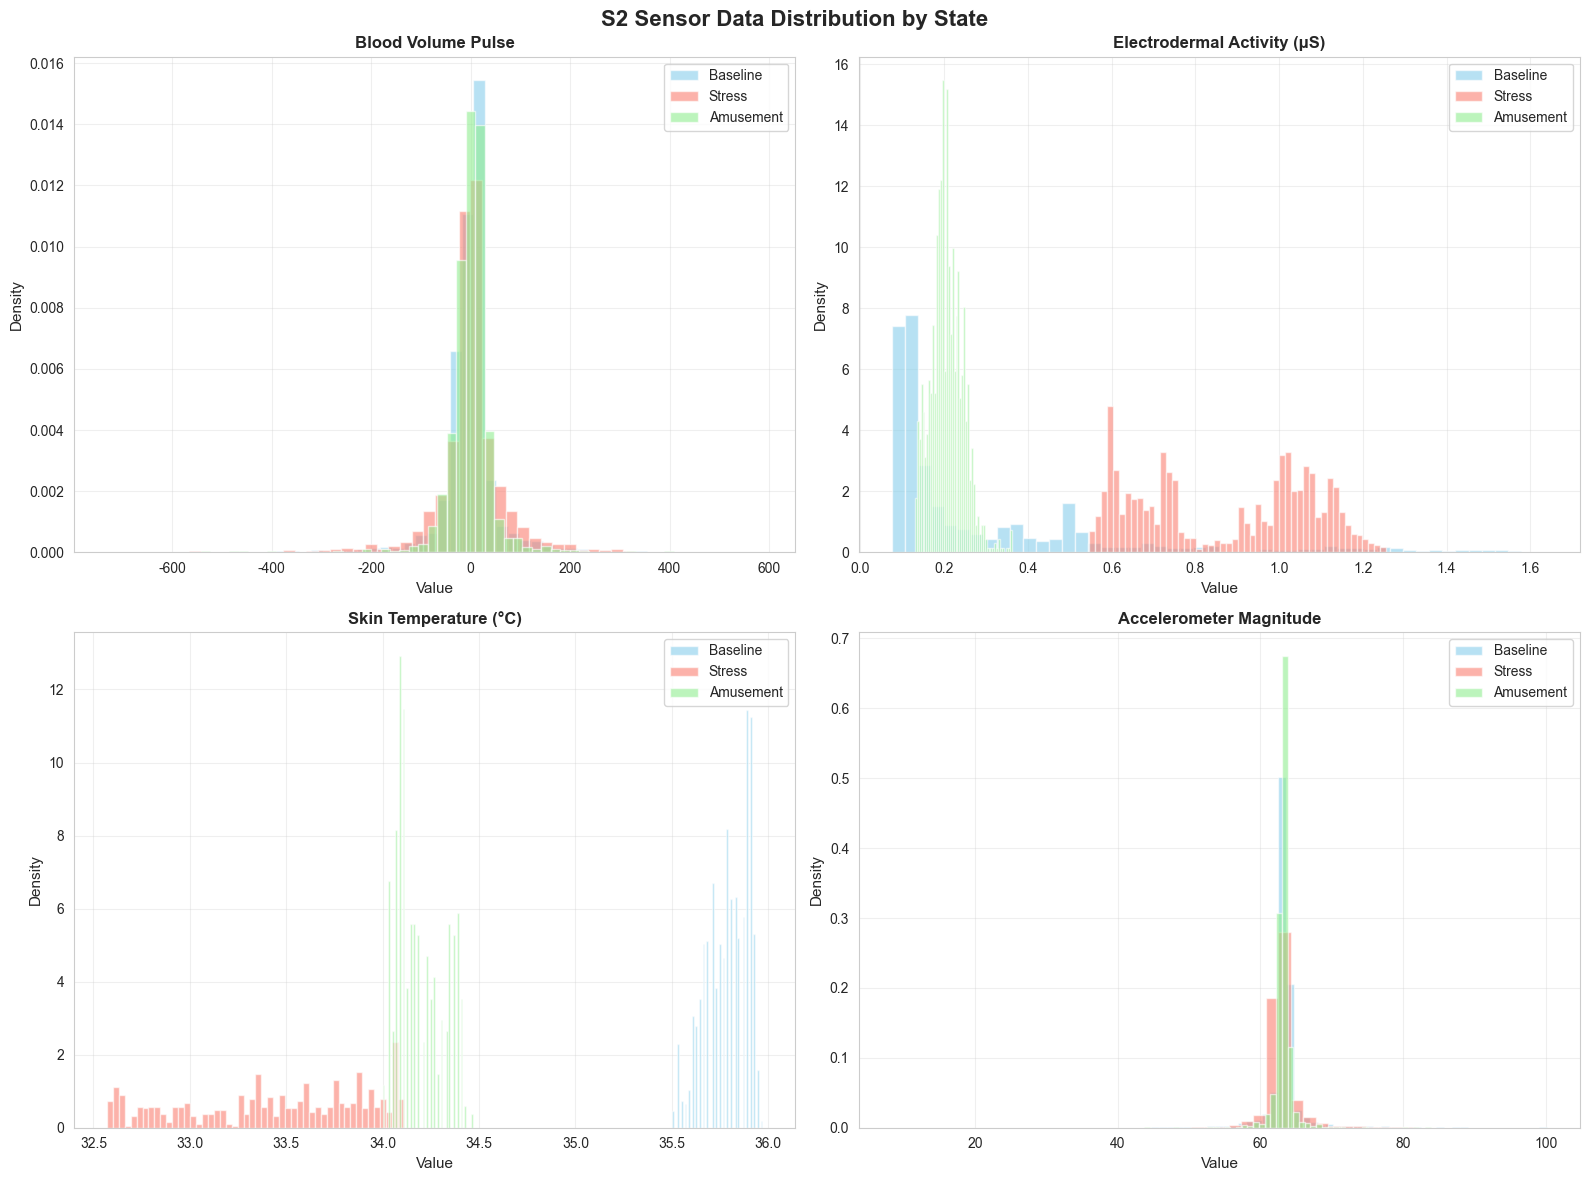

In [14]:
if data is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{sample_subject} Sensor Data Distribution by State', fontsize=16, fontweight='bold')
    
    colors_states = {'Baseline': 'skyblue', 'Stress': 'salmon', 'Amusement': 'lightgreen'}
    
    sensors = [
        ('BVP', data['bvp'], 'Blood Volume Pulse', axes[0, 0]),
        ('EDA', data['eda'], 'Electrodermal Activity (μS)', axes[0, 1]),
        ('TEMP', data['temp'], 'Skin Temperature (°C)', axes[1, 0]),
        ('ACC_mag', np.sqrt(np.sum(data['acc']**2, axis=1)), 'Accelerometer Magnitude', axes[1, 1])
    ]
    
    for sensor_name, sensor_data, title, ax in sensors:
        for label_val in TARGET_LABELS:
            mask = data['labels'] == label_val
            if mask.sum() > 0:
                label_name = LABEL_NAMES[label_val]
                if sensor_name == 'ACC_mag':
                    values = sensor_data[mask]
                else:
                    values = sensor_data[mask, 0] if len(sensor_data.shape) > 1 else sensor_data[mask]
                
                ax.hist(values, bins=50, alpha=0.6, 
                       label=label_name, density=True,
                       color=colors_states.get(label_name, 'gray'))
        
        ax.set_xlabel('Value', fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 8. 박스플롯으로 상태별 비교

C:\Users\mbnv6\AppData\Local\Temp\ipykernel_19184\1176941644.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='State', y='BVP', ax=axes[0, 0], palette=palette)
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_19184\1176941644.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='State', y='EDA', ax=axes[0, 1], palette=palette)
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_19184\1176941644.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='State', y='Temperature', ax=axes[1, 0], palette=palette)

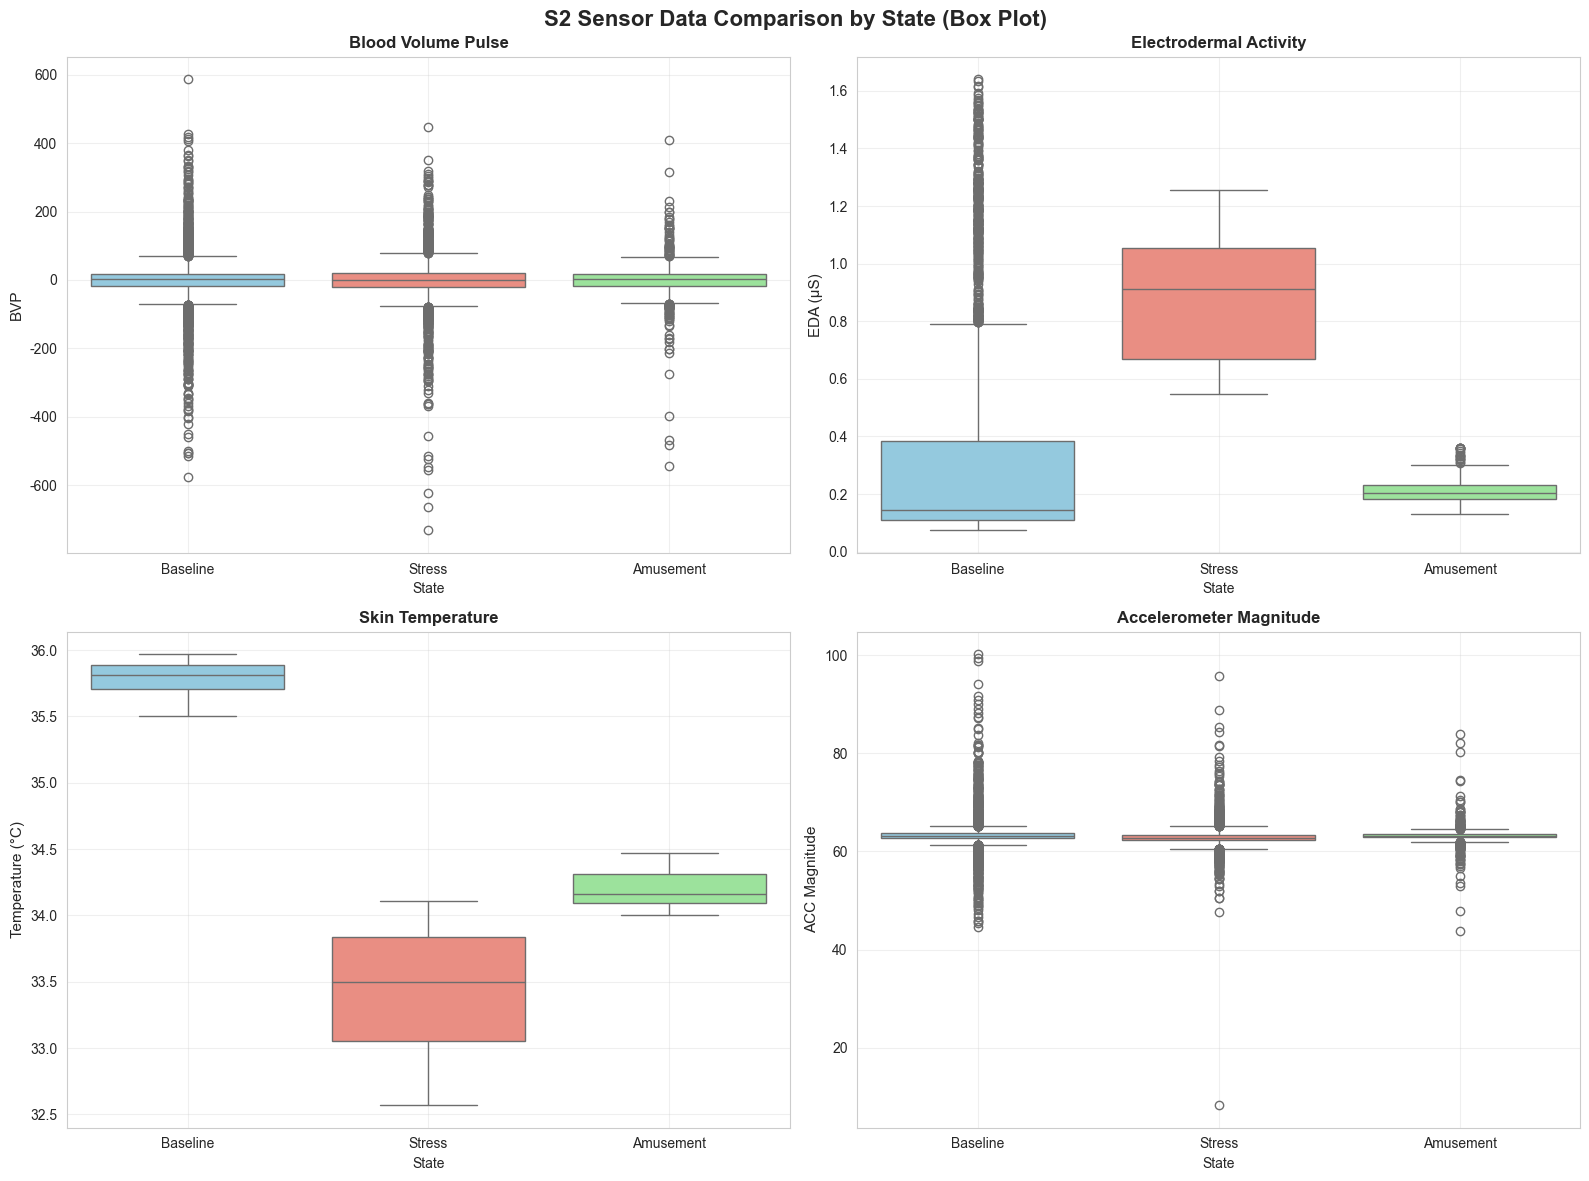

In [15]:
if data is not None:
    # 데이터 준비
    plot_data = []
    
    for label_val in TARGET_LABELS:
        mask = data['labels'] == label_val
        if mask.sum() > 0:
            label_name = LABEL_NAMES[label_val]
            
            # 샘플링 (너무 많으면 일부만 사용)
            sample_size = min(mask.sum(), 5000)
            indices = np.where(mask)[0]
            sampled_indices = np.random.choice(indices, sample_size, replace=False)
            
            for idx in sampled_indices:
                plot_data.append({
                    'State': label_name,
                    'BVP': data['bvp'][idx, 0],
                    'EDA': data['eda'][idx, 0],
                    'Temperature': data['temp'][idx, 0],
                    'ACC': np.sqrt(np.sum(data['acc'][idx]**2))
                })
    
    df_plot = pd.DataFrame(plot_data)
    
    # 박스플롯
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{sample_subject} Sensor Data Comparison by State (Box Plot)', fontsize=16, fontweight='bold')
    
    palette = {'Baseline': 'skyblue', 'Stress': 'salmon', 'Amusement': 'lightgreen'}
    
    sns.boxplot(data=df_plot, x='State', y='BVP', ax=axes[0, 0], palette=palette)
    axes[0, 0].set_title('Blood Volume Pulse', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('BVP', fontsize=11)
    axes[0, 0].grid(True, alpha=0.3)
    
    sns.boxplot(data=df_plot, x='State', y='EDA', ax=axes[0, 1], palette=palette)
    axes[0, 1].set_title('Electrodermal Activity', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('EDA (μS)', fontsize=11)
    axes[0, 1].grid(True, alpha=0.3)
    
    sns.boxplot(data=df_plot, x='State', y='Temperature', ax=axes[1, 0], palette=palette)
    axes[1, 0].set_title('Skin Temperature', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Temperature (°C)', fontsize=11)
    axes[1, 0].grid(True, alpha=0.3)
    
    sns.boxplot(data=df_plot, x='State', y='ACC', ax=axes[1, 1], palette=palette)
    axes[1, 1].set_title('Accelerometer Magnitude', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('ACC Magnitude', fontsize=11)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 9. 여러 피험자 데이터 통합 분석

In [16]:
# 여러 피험자의 데이터를 로드하여 통합 분석
all_subjects_stats = []

print("피험자 데이터 로드 중...")
for subject_id in TARGET_USERS[:5]:  # 처음 5명만 분석
    subject_data = load_subject_data(subject_id)
    if subject_data is None:
        continue
    
    print(f"  {subject_id} 처리 중...")
    
    for label_val in TARGET_LABELS:
        mask = subject_data['labels'] == label_val
        if mask.sum() == 0:
            continue
        
        acc_mag = np.sqrt(np.sum(subject_data['acc'][mask]**2, axis=1))
        
        all_subjects_stats.append({
            '피험자': subject_id,
            '상태': LABEL_NAMES[label_val],
            'BVP 평균': subject_data['bvp'][mask].mean(),
            'EDA 평균': subject_data['eda'][mask].mean(),
            '온도 평균': subject_data['temp'][mask].mean(),
            'ACC 평균': acc_mag.mean()
        })

df_all = pd.DataFrame(all_subjects_stats)
print(f"\n총 {len(df_all)} 개의 데이터 포인트 수집 완료")
print(df_all.head(10))

피험자 데이터 로드 중...
  S2 처리 중...
  S3 처리 중...
  S4 처리 중...
  S5 처리 중...
  S6 처리 중...

총 15 개의 데이터 포인트 수집 완료
  피험자         상태    BVP 평균    EDA 평균      온도 평균     ACC 평균
0  S2   Baseline -0.358011  0.297881  35.786198  63.403876
1  S2     Stress -0.635020  0.870277  33.442098  63.010803
2  S2  Amusement -0.199344  0.206203  34.190884  63.258529
3  S3   Baseline -0.173414  1.743399  33.007026  64.427419
4  S3     Stress -0.000395  2.725020  32.254969  65.185916
5  S3  Amusement -0.391113  0.385765  30.880560  63.755219
6  S4   Baseline -0.128726  0.133671  32.992271  64.624652
7  S4     Stress  1.570764  2.348948  32.461622  64.930023
8  S4  Amusement  0.634960  0.174360  32.771129  64.332803
9  S5   Baseline -0.527878  0.824152  35.020173  63.285911


## 10. 피험자 간 비교 시각화

ValueError: Could not interpret value `Subject` for `x`. An entry with this name does not appear in `data`.

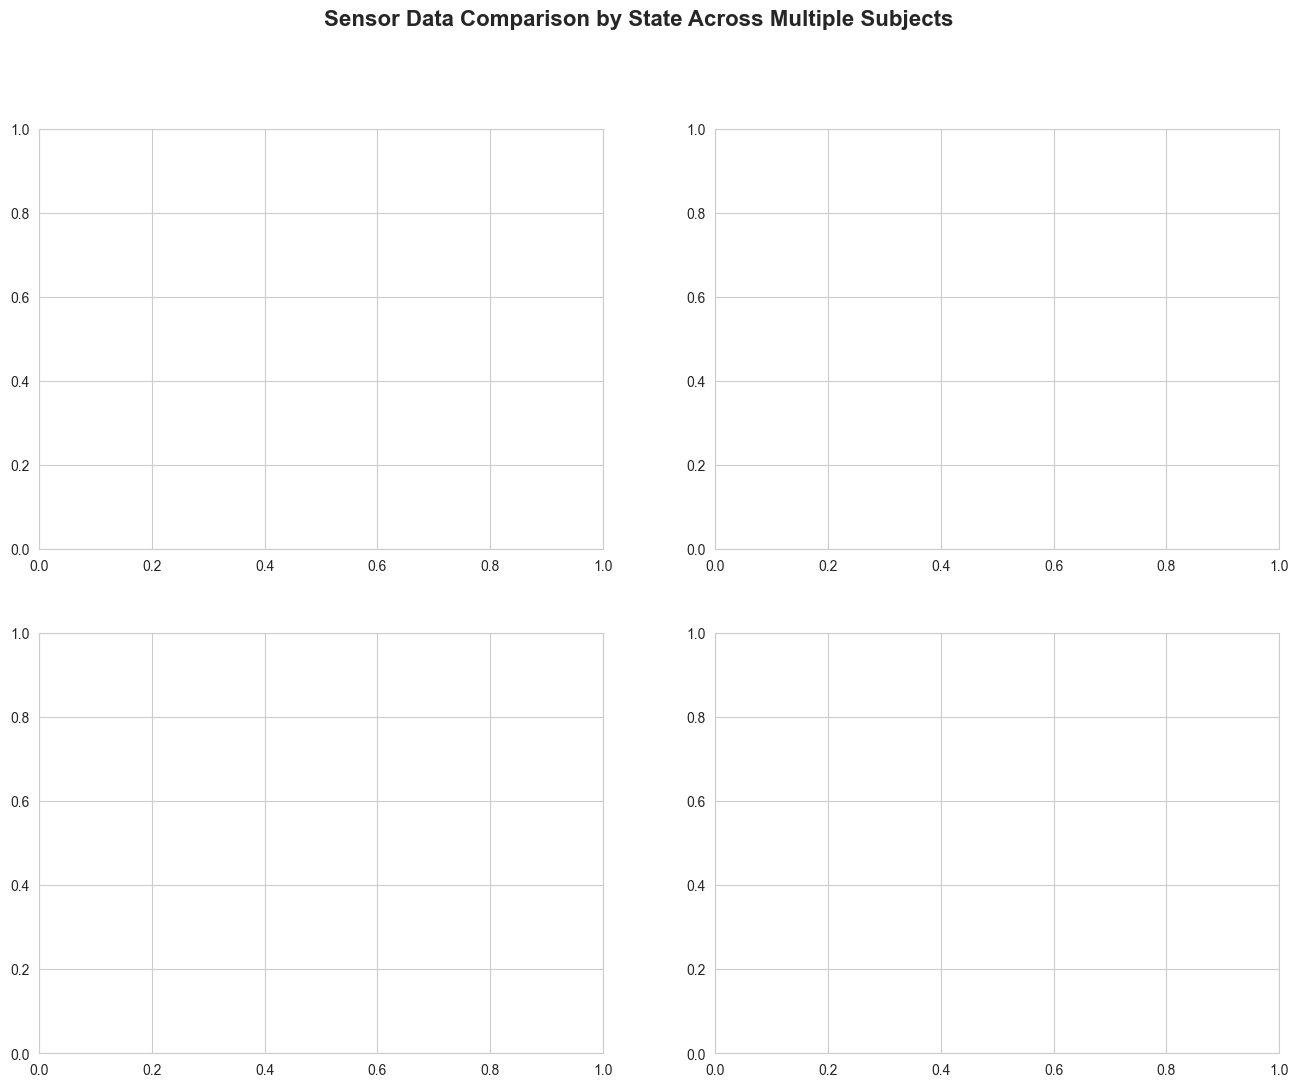

In [ ]:
if len(df_all) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Sensor Data Comparison by State Across Multiple Subjects', fontsize=16, fontweight='bold')
    
    palette = {'Baseline': 'skyblue', 'Stress': 'salmon', 'Amusement': 'lightgreen'}
    
    # BVP
    sns.barplot(data=df_all, x='피험자', y='BVP 평균', hue='상태', ax=axes[0, 0], palette=palette)
    axes[0, 0].set_title('Blood Volume Pulse Mean', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('BVP', fontsize=11)
    axes[0, 0].set_xlabel('Subject', fontsize=11)
    axes[0, 0].legend(title='State')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # EDA
    sns.barplot(data=df_all, x='피험자', y='EDA 평균', hue='상태', ax=axes[0, 1], palette=palette)
    axes[0, 1].set_title('Electrodermal Activity Mean', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('EDA (μS)', fontsize=11)
    axes[0, 1].set_xlabel('Subject', fontsize=11)
    axes[0, 1].legend(title='State')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Temperature
    sns.barplot(data=df_all, x='피험자', y='온도 평균', hue='상태', ax=axes[1, 0], palette=palette)
    axes[1, 0].set_title('Skin Temperature Mean', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Temperature (°C)', fontsize=11)
    axes[1, 0].set_xlabel('Subject', fontsize=11)
    axes[1, 0].legend(title='State')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # ACC
    sns.barplot(data=df_all, x='피험자', y='ACC 평균', hue='상태', ax=axes[1, 1], palette=palette)
    axes[1, 1].set_title('Accelerometer Magnitude Mean', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('ACC', fontsize=11)
    axes[1, 1].set_xlabel('Subject', fontsize=11)
    axes[1, 1].legend(title='State')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

## 11. 주요 발견 사항

### 각 상태의 생리학적 특징:

**🔵 Baseline (기준선)**
- 평상시 안정된 상태로 모든 센서 값이 안정적
- 비교 기준점으로 사용

**🔴 Stress (스트레스)**
- **EDA (피부전기활동) ↑↑**: 스트레스로 인한 땀샘 활동 증가
- **심박수/BVP 변화**: 교감신경 활성화
- **피부온도 변화**: 혈관 수축/이완 반응

**🟢 Amusement (즐거움)**
- **EDA**: Baseline보다 약간 높지만 Stress보다는 낮음
- **BVP**: 비교적 안정적인 패턴
- **움직임**: 웃거나 즐거워할 때의 자연스러운 움직임 증가

### 센서별 특징:
- **EDA**: 스트레스 감지에 가장 민감한 지표
- **BVP**: 심박수 변화를 통해 감정 상태 추정
- **온도**: 개인차가 크지만 감정 변화에 따른 미세한 변동 존재
- **ACC**: 신체 활동량 및 움직임 패턴 분석에 유용